In [ ]:
import os
import zipfile
import urllib.request

BASE_DIR = "gtsrb_data"
os.makedirs(BASE_DIR, exist_ok=True)

FILES = {
    "train": "https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip",
    "test": "https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip",
    "labels": "https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip"
}

def download_file(url, output_path):
    if not os.path.exists(output_path):
        print(f"Downloading {url}...")
        urllib.request.urlretrieve(url, output_path)
        print("Download completed.")
    else:
        print(f"{output_path} already exists.")

def extract_zip(zip_path, extract_to):
    print(f"Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print("Extraction done.")

for name, url in FILES.items():
    zip_path = os.path.join(BASE_DIR, f"{name}.zip")
    extract_path = os.path.join(BASE_DIR, name)

    download_file(url, zip_path)
    extract_zip(zip_path, extract_path)

print("\nGTSRB dataset is ready!")


Download completed.
Extracting gtsrb_data/train.zip...
Extraction done.
Download completed.
Extracting gtsrb_data/test.zip...
Extraction done.
Download completed.
Extracting gtsrb_data/labels.zip...
Extraction done.

GTSRB dataset is ready!


Classes: 43
Number of training images: 39209


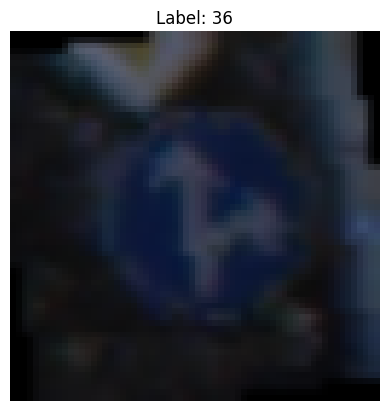

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


transform = transforms.Compose([
    transforms.RandomRotation(10),     # Rotate images slightly (+/- 10 degrees)
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Randomize lighting
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])


train_dataset = datasets.ImageFolder(
    root="/content/gtsrb_data/train/GTSRB/Final_Training/Images",
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
print("Classes:", len(train_dataset.classes))
print("Number of training images:", len(train_dataset))

# show one batch for test
images, labels = next(iter(train_loader))
plt.imshow(images[0].permute(1, 2, 0))
plt.title(f"Label: {labels[0].item()}")
plt.axis("off")
plt.show()

In [ ]:
import torch.nn as nn
import torch.nn.functional as F



class TrafficSignCNN(nn.Module):
    def __init__(self, num_classes=43):
        super(TrafficSignCNN, self).__init__()


        # Feature Extraction (Convolutional Layers)
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), # Size goes /2

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), # Size goes /4

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)  # Size goes /8
        )

        # Adaptive Pooling
        # This forces the feature map to be 1x1 regardless of input size
        # So you never have to calculate linear input sizes again.
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

In [ ]:
import torch.optim as optim
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = TrafficSignCNN(num_classes=43).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


Device: cuda


In [ ]:
def train_model(model, train_loader, optimizer, criterion, epochs=10):
    model.train()

    for epoch in range(epochs):
        running_loss = 0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        acc = 100 * correct / total
        print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss:.4f} Accuracy: {acc:.2f}%")


train_model(model, train_loader, optimizer, criterion, epochs=10)


Epoch [1/10] Loss: 3384.0799 Accuracy: 21.24%
Epoch [2/10] Loss: 2414.8303 Accuracy: 37.96%
Epoch [3/10] Loss: 1963.0506 Accuracy: 47.25%
Epoch [4/10] Loss: 1624.3234 Accuracy: 56.67%
Epoch [5/10] Loss: 1323.3702 Accuracy: 64.72%
Epoch [6/10] Loss: 1051.7676 Accuracy: 72.12%
Epoch [7/10] Loss: 843.7694 Accuracy: 77.84%
Epoch [8/10] Loss: 694.4668 Accuracy: 81.94%
Epoch [9/10] Loss: 576.8331 Accuracy: 84.96%
Epoch [10/10] Loss: 461.9968 Accuracy: 88.01%


In [ ]:
torch.save(model.state_dict(), "traffic_sign_model.pth")
print("Model saved successfully!")

Model saved successfully!


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import torch
import pandas as pd
import os
from PIL import Image

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

class GTSRBTestDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.annotations = pd.read_csv(csv_file, sep=';')
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, index):
        # The image paths in the CSV are relative to 'GTSRB/Final_Test/Images/'
        # and usually start with an additional '/' (which lstrip handles, though not strictly needed after fixing csv parsing)
        img_path = os.path.join(self.root_dir, self.annotations.iloc[index, 0].lstrip('/'))
        image = Image.open(img_path)
        y_label = torch.tensor(self.annotations.iloc[index, 7]) # Column 7 is 'ClassId'

        if self.transform:
            image = self.transform(image)

        return image, y_label

# Instantiate the custom test dataset
test_dataset = GTSRBTestDataset(
    csv_file="/content/gtsrb_data/labels/GT-final_test.csv", # The ground truth file
    root_dir="/content/gtsrb_data/test/GTSRB/Final_Test/Images", # The directory containing all test images
    transform=test_transform
)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 90.93%


In [ ]:
class_names = {
  0:  "Speed limit (20 km/h)",
  1:  "Speed limit (30 km/h)",
  2:  "Speed limit (50 km/h)",
  3:  "Speed limit (60 km/h)",
  4:  "Speed limit (70 km/h)",
  5:  "Speed limit (80 km/h)",
  6:  "End of speed limit (80 km/h)",
  7:  "Speed limit (100 km/h)",
  8:  "Speed limit (120 km/h)",

  9:  "No passing",
  10: "No passing for vehicles over 3.5 tons",

  11: "Right-of-way at the next intersection",
  12: "Priority road",
  13: "Yield",
  14: "Stop",

  15: "No vehicles",
  16: "Vehicles over 3.5 tons prohibited",
  17: "No entry",

  18: "General caution",
  19: "Dangerous curve to the left",
  20: "Dangerous curve to the right",
  21: "Double curve",
  22: "Bumpy road",
  23: "Slippery road",
  24: "Road narrows on the right",
  25: "Road work",
  26: "Traffic signals",
  27: "Pedestrians",
  28: "Children crossing",
  29: "Bicycles crossing",
  30: "Beware of ice/snow",
  31: "Wild animals crossing",

  32: "End of all speed and passing limits",

  33: "Turn right ahead",
  34: "Turn left ahead",
  35: "Ahead only",
  36: "Go straight or right",
  37: "Go straight or left",
  38: "Keep right",
  39: "Keep left",

  40: "Roundabout mandatory",

  41: "End of no passing",
  42: "End of no passing by vehicles over 3.5 tons"
}


No red traffic sign detected. Processing full image.


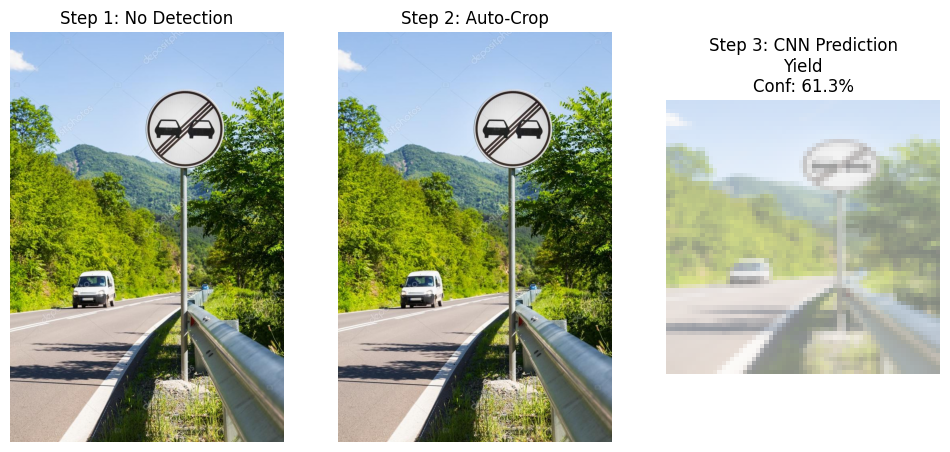

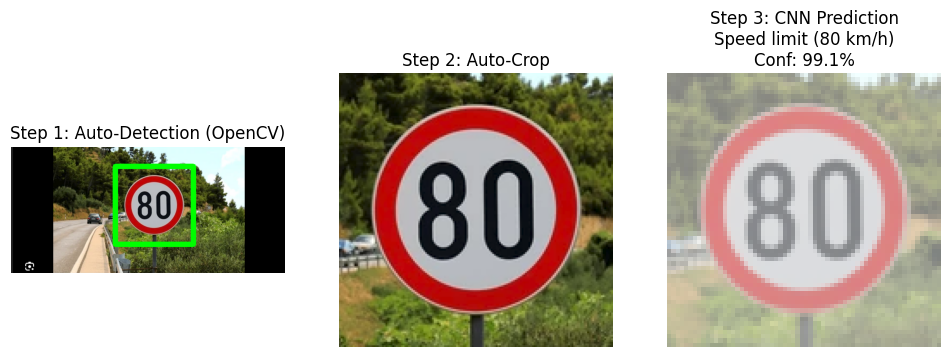

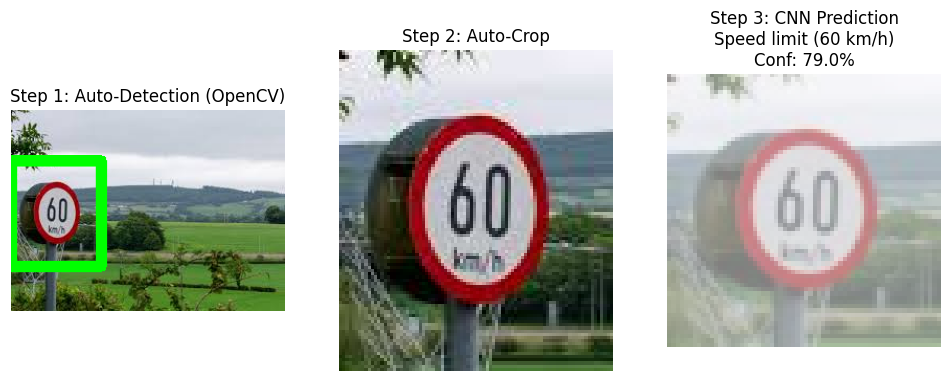

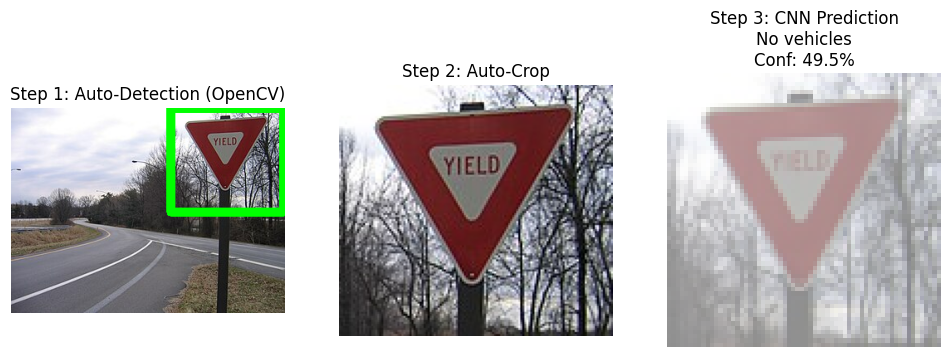

No red traffic sign detected. Processing full image.


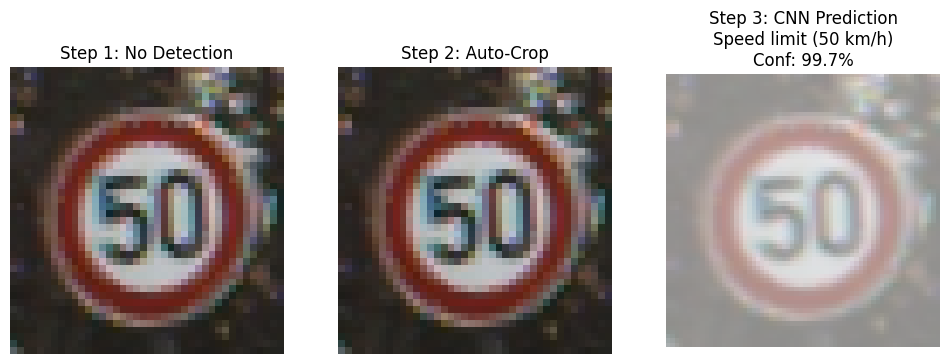

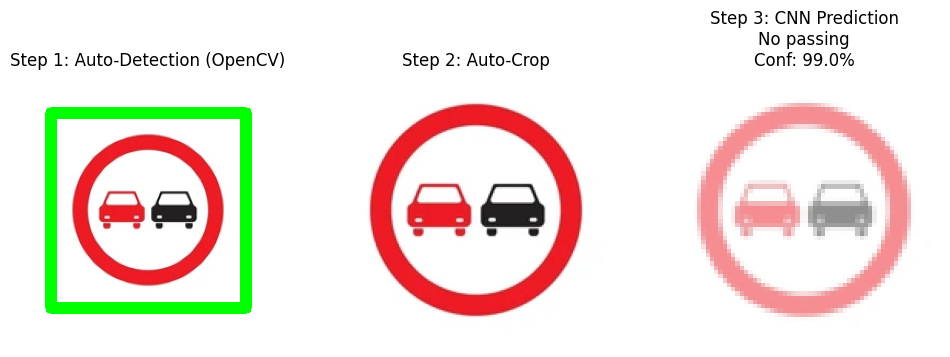

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def auto_detect_and_classify(image_path, model, transform):
    # 1. Load image with OpenCV
    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 2. Convert to HSV Color Space (Better for finding colors than RGB)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # 3. Create a Mask for the Color RED
    # Red wraps around 0 and 180 in Hue, so we need two ranges
    lower_red1 = np.array([0, 70, 50])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([170, 70, 50])
    upper_red2 = np.array([180, 255, 255])

    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    mask = mask1 + mask2

    # 4. Find contours (shapes) in the mask
    contours, _ = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    # 5. Find the largest red contour (Assuming it's the sign)
    best_cnt = None
    max_area = 0

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > 1000: # Filter out tiny noise pixels
            if area > max_area:
                max_area = area
                best_cnt = cnt

    if best_cnt is None:
        print("No red traffic sign detected. Processing full image.")
        final_img = Image.fromarray(img_rgb)
        bbox = None
    else:
        # Get bounding box coordinates
        x, y, w, h = cv2.boundingRect(best_cnt)

        # Add a little padding around the sign so it's not too tight
        pad = 20
        x = max(0, x - pad)
        y = max(0, y - pad)
        w += pad * 2
        h += pad * 2

        # Visualize the detection box on the original
        img_with_box = img_rgb.copy()
        cv2.rectangle(img_with_box, (x, y), (x+w, y+h), (0, 255, 0), 10)

        # Crop the ROI (Region of Interest)
        roi = img_rgb[y:y+h, x:x+w]

        # Handle cases where padding goes out of bounds
        if roi.size == 0:
            roi = img_rgb

        final_img = Image.fromarray(roi)
        bbox = (x,y,w,h)

    # --- CLASSIFICATION PART (Existing Model) ---
    img_tensor = transform(final_img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = F.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probs, 1)

    label = class_names[predicted.item()]

    # --- VISUALIZATION ---
    plt.figure(figsize=(12, 6))

    # Show Detection
    plt.subplot(1, 3, 1)
    if bbox:
        plt.imshow(img_with_box)
        plt.title("Step 1: Auto-Detection (OpenCV)")
    else:
        plt.imshow(img_rgb)
        plt.title("Step 1: No Detection")
    plt.axis('off')

    # Show Crop
    plt.subplot(1, 3, 2)
    plt.imshow(final_img)
    plt.title("Step 2: Auto-Crop")
    plt.axis('off')

    # Show Model Input
    plt.subplot(1, 3, 3)
    # Un-normalize for display
    tensor_view = img_tensor.cpu().squeeze().permute(1, 2, 0)
    tensor_view = tensor_view * 0.5 + 0.5
    plt.imshow(tensor_view)
    plt.title(f"Step 3: CNN Prediction\n{label}\nConf: {confidence.item()*100:.1f}%")
    plt.axis('off')

    plt.show()

# Run it on your tricky image
auto_detect_and_classify("End of no passing.jpg", model, test_transform)
auto_detect_and_classify("80km.png", model, test_transform)
auto_detect_and_classify("60.jpeg", model, test_transform)
auto_detect_and_classify("yield.jpg", model, test_transform)
auto_detect_and_classify("50.ppm", model, test_transform)
auto_detect_and_classify("endof.webp", model, test_transform)
